#### NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 8 - Mini projects (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. Here, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

In [1]:
import sys
sys.path.append('./../')
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/mosegaar/jupyter_env/bin/python -m pip install --upgrade pip' command.


In [2]:
# from utils import load_it_data, visualize_img
# import utils
import os
import matplotlib.pyplot as plt
import numpy as np
import gdown

In [3]:
###copy pasted from utils, since import did somehow not work...
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np
def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return

In [4]:

project_dir = '/home/mosegaar/NX-414-Project'
sys.path.append(project_dir)
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = os.path.join(project_dir, "IT_data.h5")
gdown.download(url, output, quiet=False, fuzzy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=372d2f57-28d0-4c3e-b963-d268279760a1
To: /home/mosegaar/NX-414-Project/IT_data.h5
100%|█████████████████████████████████████████████████████████████████████████████████████| 384M/384M [00:03<00:00, 126MB/s]


'/home/mosegaar/NX-414-Project/IT_data.h5'

In [5]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [6]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


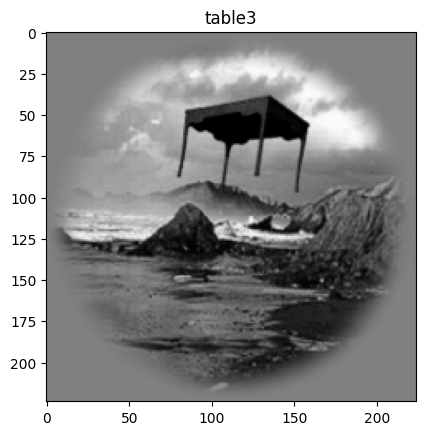

In [7]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

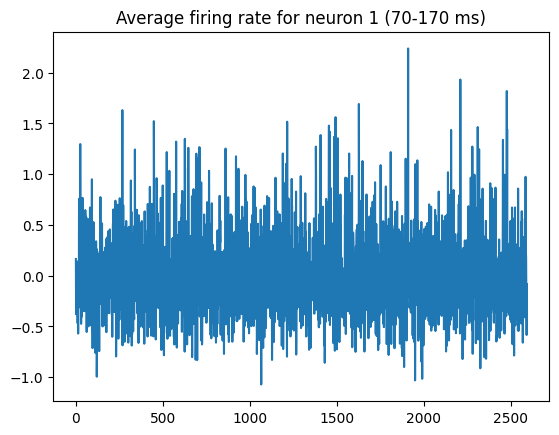

In [8]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

In [9]:
# Install timm if not already installed
# !pip install timm
import timm
import torch.nn as nn
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [10]:
# Load pretrained Vision Transformer (ViT)
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
vit_model.reset_classifier(0)  # Remove classification head
vit_model = vit_model.to(device)
vit_model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert numpy arrays to torch tensors
stimulus_train_torch = torch.tensor(stimulus_train).float()
stimulus_val_torch = torch.tensor(stimulus_val).float()

# Define normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Apply normalization
stim_train_torch = torch.stack([normalize(img) for img in stimulus_train_torch])
stim_val_torch = torch.stack([normalize(img) for img in stimulus_val_torch])

In [12]:
def create_dataloader(stimulus, spikes, batch_size):
    # Convert to TensorDataset and DataLoader for batching
    dataset = TensorDataset(stimulus, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

batch_size_train = 64
batch_size_val = 32 

# Convert your stimuli and spikes to tensors (if not already)
stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

# Create dataloaders
train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)


In [13]:
# Extract features for all training images
vit_features = []
ground_truth = []

with torch.no_grad():
    for imgs, responses in train_dataloader:
        imgs = imgs.to(device)
        features = vit_model(imgs)
        vit_features.append(features.cpu())
        ground_truth.append(responses)

vit_features = torch.cat(vit_features, dim=0)
ground_truth = torch.cat(ground_truth, dim=0)

print("Features shape:", vit_features.shape)
print("Ground truth shape:", ground_truth.shape)


Features shape: torch.Size([2592, 768])
Ground truth shape: torch.Size([2592, 168])


Mean R² score across neurons: 0.5520


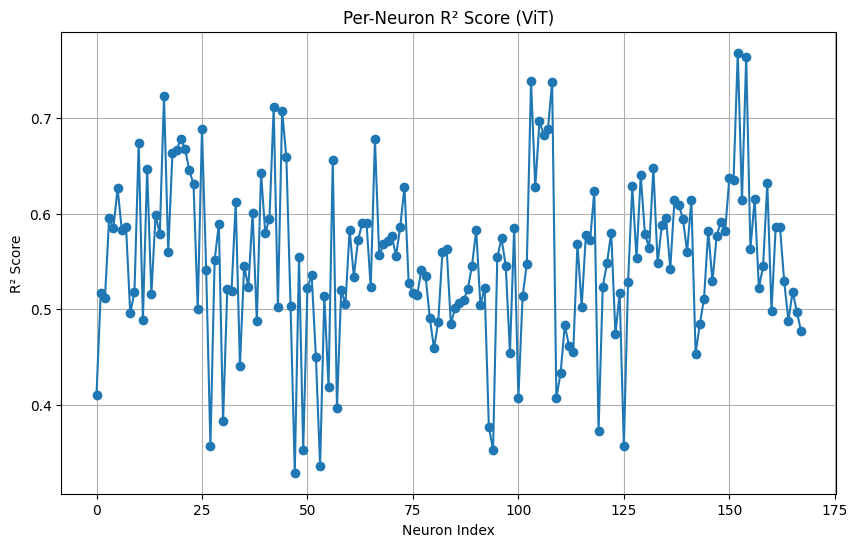

In [14]:
# Train a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

X = vit_features.numpy()
y = ground_truth.numpy()

linear_model = LinearRegression()
linear_model.fit(X, y)

# Predict on train set
y_pred = linear_model.predict(X)

# Compute R² score per neuron
r2_scores = r2_score(y, y_pred, multioutput='raw_values')
mean_r2 = np.mean(r2_scores)

print(f"Mean R² score across neurons: {mean_r2:.4f}")

# Plot per-neuron R²
plt.figure(figsize=(10,6))
plt.plot(r2_scores, marker='o')
plt.title('Per-Neuron R² Score (ViT)')
plt.xlabel('Neuron Index')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()


In [15]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Fit linear regression on training set
X_train = vit_features.numpy()
y_train = ground_truth.numpy()         

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# 2. Extract validation features
val_features = []
val_ground_truth = []

with torch.no_grad():
    for imgs, responses in val_dataloader:
        imgs = imgs.to(device)
        features = vit_model(imgs)
        val_features.append(features.cpu())
        val_ground_truth.append(responses)

val_features = torch.cat(val_features, dim=0)
val_ground_truth = torch.cat(val_ground_truth, dim=0)

X_val = val_features.numpy()  # Validation features
y_val = val_ground_truth.numpy()  # Real validation neural responses

# 3. Predict on validation set
y_pred_val = linear_model.predict(X_val)

# 4. Evaluate with Pearson correlation and explained variance
# Flatten everything
val_outputs_flat = y_pred_val.flatten()
val_labels_flat = y_val.flatten()

# Pearson Correlation
pearson_corr = np.corrcoef(val_outputs_flat, val_labels_flat)[0, 1]
print(f"Pearson Correlation (Validation Set): {pearson_corr:.4f}")

# Explained Variance Score
evs = explained_variance_score(y_val, y_pred_val)
print(f"Explained Variance Score (Validation Set): {evs:.4f}")

Pearson Correlation (Validation Set): 0.5040
Explained Variance Score (Validation Set): 0.0871


In [17]:
# ========================
# Fine-tuning ViT to predict brain responses
# ========================

import timm
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product
import random

#------ Reproducibility ------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

param_grid = {
    'lr': [1e-3, 1e-4],
    'hidden_dim': [256, 512],
    'weight_decay': [1e-5, 1e-6],
    # 'lr': [1e-4],
    # 'hidden_dim': [256],
    # 'weight_decay': [1e-6],
}

best_loss = float('inf')
best_config = None

results = []

for lr, hidden_dim, wd in product(param_grid['lr'], param_grid['hidden_dim'], param_grid['weight_decay']):
    print(f"\n Tuning with: LR={lr}, Hidden={hidden_dim}, WeightDecay={wd}")
    set_seed(42)

    # Load pretrained ViT
    vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
    vit_model.reset_classifier(0)  # Remove classification head
    feature_dim = vit_model.num_features if hasattr(vit_model, 'num_features') else vit_model.embed_dim

    # Add custom MLP head
    class ViTNeuralPredictor(nn.Module):
        def __init__(self, vit_model, feature_dim, output_dim=168):
            super(ViTNeuralPredictor, self).__init__()
            self.backbone = vit_model
            self.head = nn.Sequential(
                nn.Linear(feature_dim, 512),
                nn.ReLU(),
                nn.Linear(512, output_dim)
            )

        def forward(self, x):
            features = self.backbone(x)
            output = self.head(features)
            return output
        

    model = ViTNeuralPredictor(vit_model, feature_dim).to(device)

    # Optimizer, loss
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    # Training loop
    NUM_EPOCHS = 10
    losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0

        for imgs, responses in train_dataloader:
            imgs = imgs.to(device)
            responses = responses.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, responses)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {avg_loss:.4f}")
        
    final_loss = losses[-1]
    results.append({'lr': lr, 'hidden_dim': hidden_dim, 'weight_decay': wd, 'final_loss': final_loss})

    if final_loss < best_loss:
        best_loss = final_loss
        best_config = {'lr': lr, 'hidden_dim': hidden_dim, 'weight_decay': wd}
    
        # Save the best model checkpoint
        torch.save({
            'model_state_dict': model.state_dict(),
            'vit_model_config': vit_model.default_cfg,
            'feature_dim': feature_dim,
            'best_config': best_config
        }, 'best_vit_model.pth')
        

print("Grid Search Complete!")
print(f"Best configuration: {best_config} with loss: {best_loss:.4f}")

sorted_results = sorted(results, key=lambda x: x['final_loss'])
print("All configs ranked:")
for r in sorted_results:
    print(f"  LR={r['lr']}, Hidden={r['hidden_dim']}, WD={r['weight_decay']} → Loss={r['final_loss']:.4f}")


 Tuning with: LR=0.001, Hidden=256, WeightDecay=1e-05


Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1319
Epoch [3/10] - Train Loss: 0.1247
Epoch [4/10] - Train Loss: 0.1142
Epoch [5/10] - Train Loss: 0.0985
Epoch [6/10] - Train Loss: 0.0884
Epoch [7/10] - Train Loss: 0.0782
Epoch [8/10] - Train Loss: 0.0691
Epoch [9/10] - Train Loss: 0.0612
Epoch [10/10] - Train Loss: 0.0534

 Tuning with: LR=0.001, Hidden=256, WeightDecay=1e-06
Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1326
Epoch [3/10] - Train Loss: 0.1259
Epoch [4/10] - Train Loss: 0.1153
Epoch [5/10] - Train Loss: 0.1002
Epoch [6/10] - Train Loss: 0.0891
Epoch [7/10] - Train Loss: 0.0791
Epoch [8/10] - Train Loss: 0.0701
Epoch [9/10] - Train Loss: 0.0629
Epoch [10/10] - Train Loss: 0.0550

 Tuning with: LR=0.001, Hidden=512, WeightDecay=1e-05
Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1325
Epoch [3/10] - Train Loss: 0.1262
Epoch [4/10] - Train Loss: 0.1141
Epoch [5/10] - Train Loss: 0.0987
Epoch [6/10] - Train Loss: 0.0872
Epoc

In [18]:
checkpoint = torch.load("best_vit_model.pth", map_location=device)

# Load pretrained backbone
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
vit_model.reset_classifier(0)  # remove classification head

# Rebuild and load full model
feature_dim = checkpoint['feature_dim']
model = ViTNeuralPredictor(vit_model, feature_dim).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

ViTNeuralPredictor(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximat

In [19]:
from sklearn.metrics import explained_variance_score
# Evaluate the model on the validation set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Compute Pearson Correlation
    pearson_corr = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
    print(f"Pearson Correlation: {pearson_corr:.4f}")

    # Compute Explained Variance Score
    evs = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs:.4f}")

Pearson Correlation: 0.6887
Explained Variance Score: 0.4008
